# 라이브러리 호출

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("bat_process.csv",encoding= 'cp949')

df1 =pd.read_csv("bat_tat.csv")

In [19]:
df['is_defect'] = df['judge'].apply(lambda x: 1 if x == '불량' else 0)

In [20]:
df2 = df1.merge(df)

In [21]:
df2

,lot_id,tray_id,rta1_tat,hta1_tat,rta2_tat,ocv1_tat,c1_tat,dc1_tat,c2_tat,dc2_tat,...,sa3_box_dan,socv3_ocv,ocv2_deltaocv,ocv1_deltaocv,m1_thick,m1_voltage,m1_res_ac,m1_mv,m1_voltage_an,is_defect
0,LOT-100,TRAY-1002,217709,86476,4524,118,3580,405,453,405,...,10단,3759.6,5.0,6.8,4709.0,37583.0,92.0,626.0,109.0,0
1,LOT-100,TRAY-1002,217709,86476,4524,118,3580,405,453,405,...,10단,3760.4,5.1,6.8,4712.0,37591.0,92.0,606.0,5.0,0
2,LOT-100,TRAY-1002,217709,86476,4524,118,3580,405,453,405,...,10단,3760.4,4.9,6.7,4737.0,37594.0,92.0,566.0,-10.0,0
3,LOT-100,TRAY-1002,217709,86476,4524,118,3580,405,453,405,...,10단,3759.0,5.1,6.9,4709.0,37578.0,92.0,606.0,111.0,0
4,LOT-100,TRAY-1002,217709,86476,4524,118,3580,405,453,405,...,10단,3759.0,5.0,6.7,4706.0,37577.0,93.0,606.0,-38.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38590,LOT-144,TRAY-2791,152836,87334,156490,118,3553,405,451,405,...,13단,3759.2,5.3,7.2,4745.0,37583.0,94.0,643.0,-35.0,0
38591,LOT-144,TRAY-2791,152836,87334,156490,118,3553,405,451,405,...,13단,3759.2,5.3,7.1,4746.0,37583.0,94.0,620.0,89.0,0
38592,LOT-144,TRAY-2791,152836,87334,156490,118,3553,405,451,405,...,13단,3760.3,5.2,7.0,4782.0,37595.0,92.0,597.0,-23.0,0
38593,LOT-144,TRAY-2791,152836,87334,156490,118,3553,405,451,405,...,13단,3760.0,5.3,7.0,4751.0,37590.0,95.0,620.0,3.0,0


In [22]:
ocv1df = df2[["ocv1_tat","ocv1_ocv","ocv1_box_col","ocv1_box_dan"]]

In [28]:
ocv1df

,ocv1_tat,ocv1_ocv,ocv1_box_col,ocv1_box_dan
0,118,3337,06열,09단
1,118,3333,06열,09단
2,118,3354,06열,09단
3,118,3336,06열,09단
4,118,3338,06열,09단
...,...,...,...,...
38590,118,3320,02열,05단
38591,118,3322,02열,05단
38592,118,3329,02열,05단
38593,118,3325,02열,05단


In [29]:
ocv1df_judge = df2[["ocv1_ocv","is_defect"]]

In [50]:
from scipy import stats

# 검정을 위해 각 열(Series)을 변수에 할당
ocv_values = df2['ocv1_ocv']
defect_status = df2['is_defect']

# 포인트-바이시리얼 상관계수와 p-value 계산
correlation, p_value = stats.pointbiserialr(defect_status, ocv_values)

print(f"상관계수: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

# --- 결과 해석 ---
alpha = 0.05  # 유의수준 5%
if p_value < alpha:
    print(f"\nP-value가 유의수준({alpha})보다 작으므로, 귀무가설을 기각합니다.")
    print("결론: 'ocv1_ocv'와 'is_defect' 간에는 통계적으로 유의한 상관관계가 존재합니다.")
else:
    print(f"\nP-value가 유의수준({alpha})보다 크거나 같으므로, 귀무가설을 기각할 수 없습니다.")
    print("결론: 'ocv1_ocv'와 'is_defect' 간의 상관관계가 통계적으로 유의미하다고 할 수 없습니다.")


상관계수: -0.0343
P-value: 0.0000

P-value가 유의수준(0.05)보다 작으므로, 귀무가설을 기각합니다.
결론: 'ocv1_ocv'와 'is_defect' 간에는 통계적으로 유의한 상관관계가 존재합니다.


In [49]:
# 1. ocv1_tat (수치형)와 ocv1_ocv (수치형)의 관계 분석
print("--- ocv1_tat vs ocv1_ocv (피어슨 상관 분석) ---")
corr_tat, p_val_tat = stats.pearsonr(ocv1df['ocv1_tat'], ocv1df['ocv1_ocv'])
print(f"상관계수: {corr_tat:.4f}, P-value: {p_val_tat:.4f}")
if p_val_tat < alpha:
    print("결론: ocv1_tat와 ocv1_ocv 간에 유의미한 선형 관계가 있습니다.\n")
else:
    print("결론: ocv1_tat와 ocv1_ocv 간에 유의미한 선형 관계가 없습니다.\n")

--- ocv1_tat vs ocv1_ocv (피어슨 상관 분석) ---
상관계수: 0.0433, P-value: 0.0000
결론: ocv1_tat와 ocv1_ocv 간에 유의미한 선형 관계가 있습니다.



In [54]:
    use_cols_process = ['lot_id', 'tray_id', 'ocv1_ocv']
    df_process = pd.read_csv("bat_process.csv", usecols=use_cols_process , encoding = "utf-8")

    use_cols_tat = ['lot_id', 'tray_id', 'rta1_tat', 'hta1_tat', 'rta2_tat', 'ocv1_tat']
    df_tat = pd.read_csv("bat_tat.csv", usecols=use_cols_tat, encoding = "utf-8")

    # 2. 데이터 병합
    df_merged = pd.merge(df_process, df_tat, on=['lot_id', 'tray_id'])

    # 3. 분석할 변수 리스트
    variables_to_analyze = ['ocv1_ocv', 'rta1_tat', 'hta1_tat', 'rta2_tat', 'ocv1_tat']

    # 4. 상관관계 행렬(r) 계산
    correlation_matrix = df_merged[variables_to_analyze].dropna().corr()

    # 5. 결정계수(R-squared) 계산
    r_squared_matrix = correlation_matrix ** 2
    
    # 6. 'ocv1_ocv'와 다른 변수들 간의 R-squared 값만 추출
    r_squared_values = r_squared_matrix['ocv1_ocv']
    
    # 7. 타겟 변수('ocv1_ocv') 자신을 제외
    # .drop()을 사용하여 'ocv1_ocv' 행을 제거합니다.
    r_squared_without_target = r_squared_values.drop('ocv1_ocv')
    
    # 8. 내림차순으로 정렬
    r_squared_sorted = r_squared_without_target.sort_values(ascending=False)

    print("--- 'ocv1_ocv'에 대한 결정계수(R-squared) 값 (타겟 변수 제외) ---")
    print("(해석: 'ocv1_ocv' 변동성의 몇 %를 설명하는가)")
    print(r_squared_sorted)
    print("------------------------------------------------------------------")
    
    # R-squared 값을 %로 변환하여 보기 쉽게 출력
    print("\n--- R-squared (백분율 %) ---")
    print((r_squared_sorted * 100).map("{:.4f}%".format))
    print("-------------------------------")


--- 'ocv1_ocv'에 대한 결정계수(R-squared) 값 (타겟 변수 제외) ---
(해석: 'ocv1_ocv' 변동성의 몇 %를 설명하는가)
rta1_tat    0.013855
rta2_tat    0.006350
hta1_tat    0.004799
ocv1_tat    0.001873
Name: ocv1_ocv, dtype: float64
------------------------------------------------------------------

--- R-squared (백분율 %) ---
rta1_tat    1.3855%
rta2_tat    0.6350%
hta1_tat    0.4799%
ocv1_tat    0.1873%
Name: ocv1_ocv, dtype: object
-------------------------------


/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:30: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_13912/467347458.py:33:

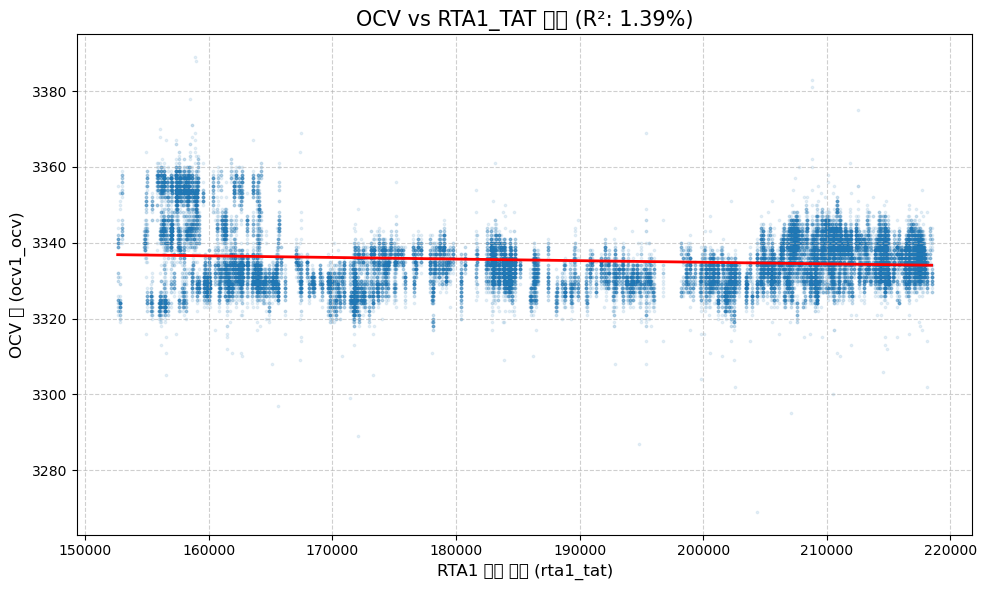

In [57]:

    
    # 2. 데이터 병합
    df_merged = pd.merge(df_process, df_tat, on=['lot_id', 'tray_id'])

    # 3. 플롯을 위해 결측치(NaN) 제거
    df_plot = df_merged.dropna(subset=['ocv1_ocv', 'rta1_tat'])

    # 4. 시각화: regplot (Scatterplot + Regression Line)
    plt.figure(figsize=(10, 6))
    
    # regplot을 사용하여 산점도와 회귀선을 함께 그립니다.
    sns.regplot(
        x='rta1_tat', 
        y='ocv1_ocv', 
        data=df_plot,
        # 회귀선을 강조하기 위해 빨간색으로 지정
        line_kws={"color": "red", "linewidth": 2},
        # 점이 많으므로(Overplotting) 투명도(alpha)와 크기(s)를 조절
        scatter_kws={"alpha": 0.1, "s": 3} 
    )
    
    # R-squared 값 (1.3855%)을 제목에 포함
    # 상관계수 r = -0.1177, R^2 = 0.013855
    r_value = -0.1177
    r_squared_value = 0.013855
    
    plt.title(f"OCV vs RTA1_TAT 관계 (R²: {r_squared_value*100:.2f}%)", fontsize=15)
    plt.xlabel("RTA1 공정 시간 (rta1_tat)", fontsize=12)
    plt.ylabel("OCV 값 (ocv1_ocv)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # 5. 그래프 파일로 저장
    plt.savefig("ocv_vs_rta1_tat_scatterplot.png")
